# Bigram Language Model

This notebook implements a bigram character-level language model from scratch using PyTorch. We'll explore:

1. **Statistical Approach**: Building bigram probabilities from a dataset
2. **Neural Network Approach**: Learning the same probabilities using gradient descent
3. **Comparison**: Understanding the connection between both approaches

A bigram model predicts the next character based only on the current character, making it one of the simplest language models.

In [1]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
%matplotlib inline

## Setup and Data Loading

We'll use a simple character-level dataset of names. Each name will be processed to create bigram pairs (character transitions).

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
words = open('dataset/names.txt', 'r').read().splitlines()
print(f'Number of names: {len(words)}')
print(f'Min length: {min(len(word) for word in words)} | Max length: {max(len(word) for word in words)}')

Number of names: 32033
Min length: 2 | Max length: 15


## Statistical Bigram Analysis

First, we'll analyze the frequency of each character pair (bigram) in the dataset. We add special start/end tokens ('.') to handle word boundaries.

In [4]:
fre = {}
for word in words:
    chs = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        fre[(ch1, ch2)] = fre.get((ch1,ch2), 0) + 1
sorted(fre.items(), key = lambda kv: -kv[1])

[(('n', '.'), 6763),
 (('a', '.'), 6640),
 (('a', 'n'), 5438),
 (('.', 'a'), 4410),
 (('e', '.'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('.', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('.', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '.'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('.', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '.'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('.', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '.'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('.', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('.', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('.', 'l'), 1572),
 (('.', 'c'), 1542),
 (('.', 'e'), 1531),
 (('j', 'a'), 1473),
 (('r', '.'), 1377),
 (('n', 'e'),

## Building the Count Matrix

We create a 27×27 matrix (26 letters + start/end token) to count the occurrences of each bigram pair.

In [5]:
N = torch.zeros((27,27), dtype=torch.int32).to(device)
chars = sorted(list(set(''.join(words))))
stoi = {ch: idx + 1 for idx, ch in enumerate(chars)}
stoi['.'] = 0
itos = {idx: ch for ch, idx in stoi.items()}

In [6]:
for chs, f in fre.items():
    N[stoi[chs[0]], stoi[chs[1]]] = f

## Visualizing the Bigram Matrix

The heatmap shows the frequency of each character pair. Darker colors indicate higher frequency. For example, you'll see common transitions like 'th', 'he', 'in', etc.

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

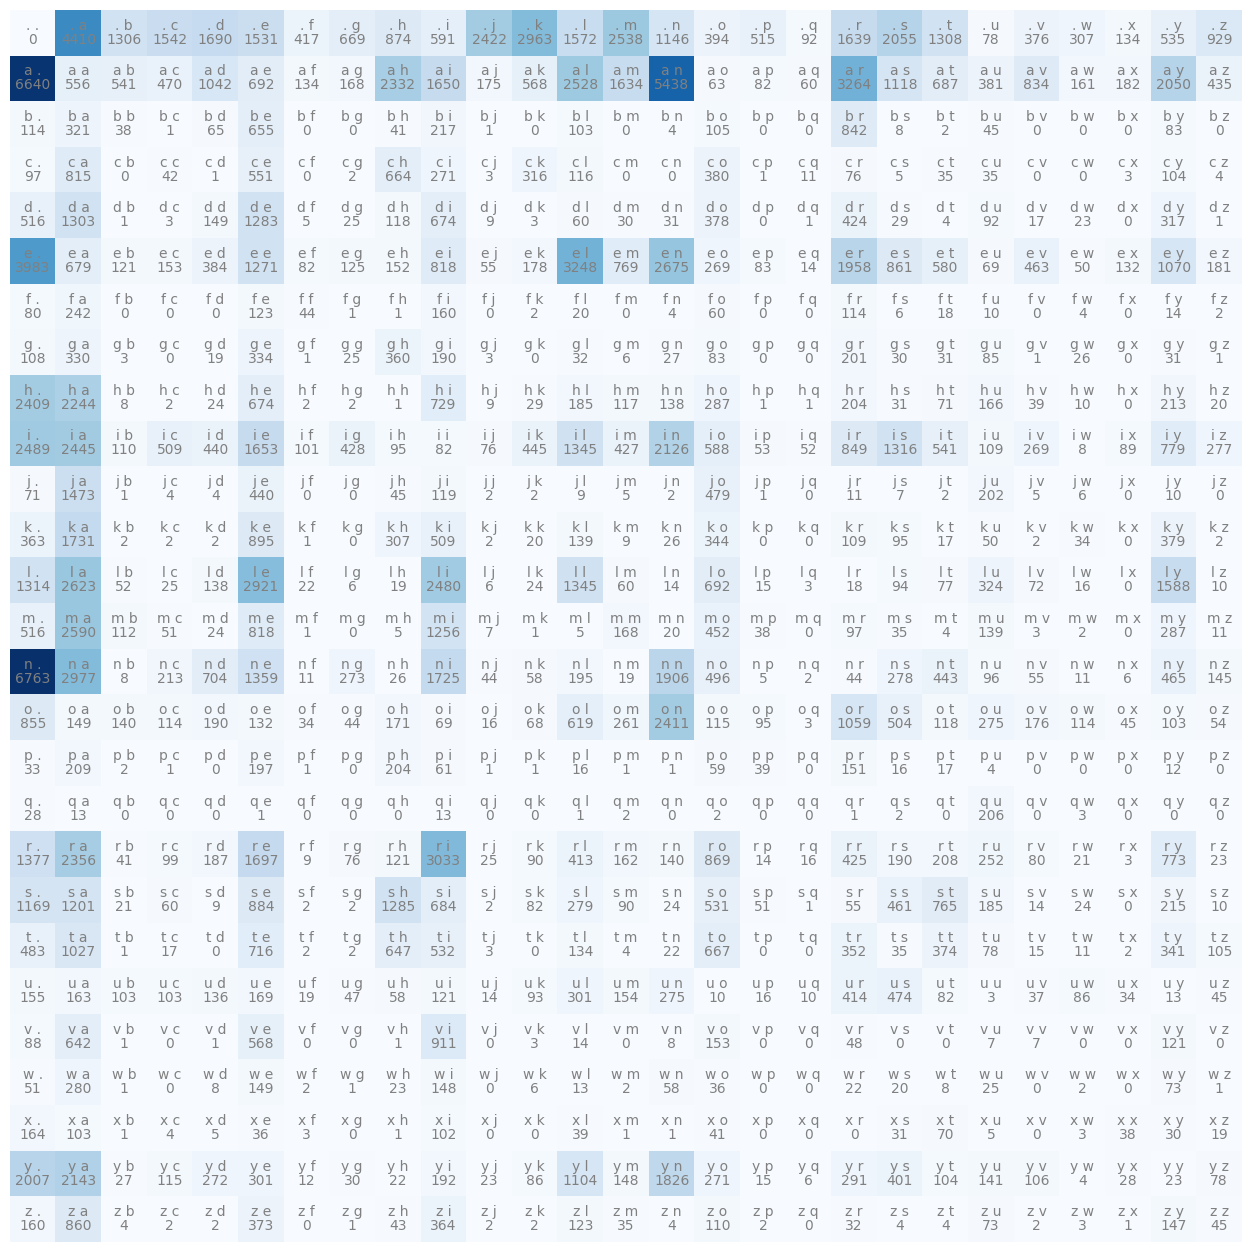

In [7]:
plt.figure(figsize=(16,16))
plt.imshow(N.cpu(), cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + " " + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off')

In [8]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290],
       device='cuda:0')

In [9]:
g = torch.Generator(device=device).manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'k'

## Converting Counts to Probabilities

We normalize the count matrix to get probabilities. We add 1 (Laplace smoothing) to avoid zero probabilities for unseen bigrams.

In [10]:
P = (N+1).float()
P /= P.sum(1, keepdims=True)

## Generating Names with Statistical Model

Now we can generate names by sampling from our probability distribution. Starting from the start token '.', we repeatedly sample the next character until we reach the end token.

In [11]:
for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

he.
ke.
wylilmorilageli.
ahan.
ramalyama.


## Evaluating the Statistical Model

We evaluate our model by calculating the negative log likelihood (NLL) of the training data. Lower NLL indicates better performance. This measures how well our probabilities match the actual data.

In [22]:
log_likehood = 0.0
n = 0
for word in words:
    chs = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        log_likehood += torch.log(P[stoi[ch1], stoi[ch2]])
        n += 1
print(f'{log_likehood=}')
nll = - log_likehood
print(f'{nll=}')
print(f'{nll/n}')

log_likehood=tensor(-559951.5625, device='cuda:0')
nll=tensor(559951.5625, device='cuda:0')
2.4543564319610596


## Neural Network Approach

Now we'll implement the same bigram model using a neural network with gradient descent. The network will learn the probabilities directly from data.

In [13]:
xs, ys = [], []

for word in words[0:1]:
    chs = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        xs.append(idx1)
        ys.append(idx2)

    xs = torch.tensor(xs, device=device)
    ys = torch.tensor(ys, device=device)

In [14]:
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0')

In [15]:
W = torch.randn((27,27), device=device)
xenc @ W

tensor([[-0.7421,  0.9144, -0.9840, -0.8075, -0.0891,  0.6619, -0.9993, -0.2337,
          0.0999,  0.8283, -1.9695,  0.9601,  0.6678,  2.1256, -1.0150, -1.1664,
         -0.1792, -0.5219, -0.2235, -0.5391,  0.3499,  0.4456,  0.9605, -0.5283,
         -0.6452,  0.5214, -1.1662],
        [ 0.1627,  1.3394, -0.5629, -0.0701, -1.5663, -1.1538, -0.0969, -0.2654,
         -0.8596, -0.4310, -0.0154,  1.0477, -1.8359,  0.9873,  1.1038,  1.1002,
         -1.5369, -0.4254,  1.2472,  1.3548, -0.7596,  0.0897, -0.1604,  0.4812,
          1.3943, -0.0473,  0.7076],
        [-0.4870,  0.9238,  1.4286, -1.6226, -0.2586, -0.0614, -1.2027,  0.5285,
         -0.1354, -2.0476,  0.7442, -0.0143,  0.6797, -2.3023,  0.5698, -0.8339,
          1.3727, -0.8501,  1.3675, -1.0969,  0.7831,  0.9930,  0.2004, -0.5027,
          0.1257, -0.0917, -0.4664],
        [-0.4870,  0.9238,  1.4286, -1.6226, -0.2586, -0.0614, -1.2027,  0.5285,
         -0.1354, -2.0476,  0.7442, -0.0143,  0.6797, -2.3023,  0.5698, -0.8339

In [16]:
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
probs

tensor([[0.0131, 0.0684, 0.0103, 0.0122, 0.0251, 0.0532, 0.0101, 0.0217, 0.0303,
         0.0628, 0.0038, 0.0716, 0.0535, 0.2297, 0.0099, 0.0085, 0.0229, 0.0163,
         0.0219, 0.0160, 0.0389, 0.0428, 0.0717, 0.0162, 0.0144, 0.0462, 0.0085],
        [0.0282, 0.0914, 0.0136, 0.0223, 0.0050, 0.0076, 0.0217, 0.0184, 0.0101,
         0.0156, 0.0236, 0.0683, 0.0038, 0.0643, 0.0723, 0.0720, 0.0052, 0.0157,
         0.0834, 0.0929, 0.0112, 0.0262, 0.0204, 0.0388, 0.0966, 0.0229, 0.0486],
        [0.0163, 0.0670, 0.1110, 0.0052, 0.0205, 0.0250, 0.0080, 0.0451, 0.0232,
         0.0034, 0.0560, 0.0262, 0.0525, 0.0027, 0.0470, 0.0116, 0.1049, 0.0114,
         0.1044, 0.0089, 0.0582, 0.0718, 0.0325, 0.0161, 0.0302, 0.0243, 0.0167],
        [0.0163, 0.0670, 0.1110, 0.0052, 0.0205, 0.0250, 0.0080, 0.0451, 0.0232,
         0.0034, 0.0560, 0.0262, 0.0525, 0.0027, 0.0470, 0.0116, 0.1049, 0.0114,
         0.1044, 0.0089, 0.0582, 0.0718, 0.0325, 0.0161, 0.0302, 0.0243, 0.0167],
        [0.0724, 0.0408,

## Neural Network Architecture

Our network consists of a single weight matrix W (27×27). Each row represents the logits for possible next characters given the current character.

In [17]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g).to(device)

In [18]:
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)

## Training the Neural Network

We train the network using gradient descent to minimize the negative log likelihood. The network learns to predict the same probabilities as our statistical approach, but through optimization rather than counting.

In [19]:
xs, ys = [], []

for word in words:
    chs = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])

xs = torch.tensor(xs, device=device)
ys = torch.tensor(ys, device=device)

num = xs.nelement()
print('Num of examples: ', num)

g = torch.Generator(device=device).manual_seed(2147483647)
W = torch.randn((27,27), generator=g, device=device)
W.requires_grad = True

Num of examples:  228146


In [20]:
for k in range(200):

  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float()
  logits = xenc @ W
  counts = logits.exp()
  probs = counts / counts.sum(1, keepdim=True)
  
  # loss calculation
  loss = -probs[torch.arange(len(xs)), ys].log().mean()
  
  # backward pass
  W.grad = None
  loss.backward()
  
  # update
  W.data += -50 * W.grad
  
  if k % 10 == 0:
    print(k, loss.item())

0 3.710920810699463
10 2.6671009063720703
20 2.5649750232696533
30 2.5266387462615967
40 2.5072996616363525
50 2.495802164077759
60 2.488123893737793
70 2.4825923442840576
80 2.478419303894043
90 2.475179433822632
100 2.4726130962371826
110 2.4705495834350586
120 2.4688687324523926
130 2.4674813747406006
140 2.466323137283325
150 2.465344190597534
160 2.4645063877105713
170 2.463782787322998
180 2.463151216506958
190 2.462594747543335


## Generating Names with Neural Network

After training, our neural network should generate names similar to the statistical approach. The learned probabilities should closely match to counted frequencies.

In [21]:
g = torch.Generator(device=device).manual_seed(2147483647)
for i in range(5):
  out = []
  ix = 0
  while True:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float().to(device)
    logits = xenc @ W 
    counts = logits.exp()
    p = counts / counts.sum(1, keepdims=True)
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

khe.
ke.
wylilmorilageli.
ahan.
ramalyama.
